In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from scipy.interpolate import interp1d,PchipInterpolator
import kuibit.simdir as SD
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import glob
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
import pickle
from Modules.eos_bar_analytic import EOS_Piecewise_Poly
import bisect


In [2]:
freq_code_u_to_hz = 203000
mn = 939.56
n0 = 0.16
epsilon = mn*n0
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)

In [31]:
p_central = np.logspace(-2,np.log10(5),100)

In [4]:
def fit_model(k2T,a0,a1,a2,a3,a4):
    return a0*((1.0 + a1*k2T + a2*(k2T**2))/(1.0 + a3*k2T + a4*(k2T**2)))

In [5]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [6]:
RVSS_cs2p_interp = {}
mu_idx_V = bisect.bisect_right(EOS_V.chem_pot_unified,980)
mu_fit_V = EOS_V.chem_pot_unified[mu_idx_V:]

mu_idx_IV = bisect.bisect_right(EOS_IV.chem_pot_unified,980)
mu_fit_IV = EOS_V.chem_pot_unified[mu_idx_IV:]

mu_idx_III = bisect.bisect_right(EOS_III.chem_pot_unified,980)
mu_fit_III = EOS_V.chem_pot_unified[mu_idx_III:]

mu_idx_II = bisect.bisect_right(EOS_II.chem_pot_unified,980)
mu_fit_II = EOS_II.chem_pot_unified[mu_idx_II:]

mu_idx_I = bisect.bisect_right(EOS_I.chem_pot_unified,980)
mu_fit_I = EOS_I.chem_pot_unified[mu_idx_I:]


EOS_V_cs2p = np.gradient(EOS_V.cs2_unified[mu_idx_V:],EOS_V.chem_pot_unified[mu_idx_V:])
EOS_IV_cs2p = np.gradient(EOS_IV.cs2_unified[mu_idx_IV:],EOS_IV.chem_pot_unified[mu_idx_IV:])
EOS_III_cs2p = np.gradient(EOS_III.cs2_unified[mu_idx_III:],EOS_III.chem_pot_unified[mu_idx_III:])
EOS_II_cs2p = np.gradient(EOS_II.cs2_unified[mu_idx_II:],EOS_II.chem_pot_unified[mu_idx_II:])
EOS_I_cs2p = np.gradient(EOS_I.cs2_unified[mu_idx_I:],EOS_I.chem_pot_unified[mu_idx_I:])



RVSS_cs2p_interp["V"] = interp1d(EOS_V.P_unified[mu_idx_V:],EOS_V_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["IV"] = interp1d(EOS_IV.P_unified[mu_idx_IV:],EOS_IV_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["III"] = interp1d(EOS_III.P_unified[mu_idx_III:],EOS_III_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["II"] = interp1d(EOS_II.P_unified[mu_idx_II:],EOS_II_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["I"] = interp1d(EOS_I.P_unified[mu_idx_I:],EOS_I_cs2p,fill_value='extrapolate')



In [7]:
solve_I = tov(epsilon,lambda p: EOS_I.eos_interp(p*epsilon)/epsilon,lambda p: EOS_I.nb_interp(p*epsilon),lambda p: EOS_I.cs2_interp(p*epsilon))
solve_II = tov(epsilon,lambda p: EOS_II.eos_interp(p*epsilon)/epsilon,lambda p: EOS_II.nb_interp(p*epsilon),lambda p: EOS_II.cs2_interp(p*epsilon))
solve_III = tov(epsilon,lambda p: EOS_III.eos_interp(p*epsilon)/epsilon,lambda p: EOS_III.nb_interp(p*epsilon),lambda p: EOS_III.cs2_interp(p*epsilon))
solve_IV = tov(epsilon,lambda p: EOS_IV.eos_interp(p*epsilon)/epsilon,lambda p: EOS_IV.nb_interp(p*epsilon),lambda p: EOS_IV.cs2_interp(p*epsilon))
solve_V = tov(epsilon,lambda p: EOS_V.eos_interp(p*epsilon)/epsilon,lambda p: EOS_V.nb_interp(p*epsilon),lambda p: EOS_V.cs2_interp(p*epsilon))

RVSS_Solver_list = {"I":solve_I,
                    "II": solve_II,
                    "III": solve_III,
                    "IV": solve_IV,
                    "V": solve_V}

In [8]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

core_subeos = {
              "DD2": "brown",
              "BHBlp": "green",
              "BLQ": "purple",
              "BLh": "black",
              "LS220": "red"}


In [9]:
p_central = np.logspace(-2,np.log10(5),100)

In [10]:

RVSS_List = {"V" : [EOS_V,'red',0.0039],  
             "IV" : [EOS_IV,'purple',0.0027],
             "III" : [EOS_III,'blue',0.0021],
             "II": [EOS_II,'green',0.0017],
             "I": [EOS_I,'black',0.0012]}   

In [11]:
RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz


In [12]:
core_mvr_data = {}
core_m_cs2_mub_Vavg_interp = {}
core_M_pcentral_interp = {}
core_M_R_interp = {}
max_mass_core = {}


for file in os.listdir('./MVR/CORE'):
    file_split = file.split("_")
    eos = file_split[0]
    mvr_data = np.loadtxt(f'./MVR/CORE/{file}',skiprows=1)
    core_mvr_data[eos] = mvr_data
    core_m_cs2_mub_Vavg_interp[eos] = interp1d(mvr_data[:,0],mvr_data[:,6])
    core_M_pcentral_interp[eos] = interp1d(mvr_data[:,0],p_central)
    core_M_R_interp[eos] = interp1d(core_mvr_data[eos][:,0],core_mvr_data[eos][:,1])
    max_mass_core[eos] = max(mvr_data[:,0])


In [13]:
rvss_mvr_data = {}
rvss_M_pcentral_interp = {}
rvss_m_cs2_mub_Vavg_interp = {}
rvss_M_R_interp = {}

for file in os.listdir('./MVR/RVSS'):
    file_split = file.split('_')
    model = file_split[0]
    rvss_mvr_data[model] = np.loadtxt(f'./MVR/RVSS/{file}',skiprows=1)
    rvss_M_pcentral_interp[model] = interp1d(rvss_mvr_data[model][:,0],p_central)
    rvss_M_R_interp[model] = interp1d(rvss_mvr_data[model][:,0],rvss_mvr_data[model][:,1])
    rvss_m_cs2_mub_Vavg_interp[model] = interp1d(rvss_mvr_data[model][:,0],rvss_mvr_data[model][:,5])

In [14]:
eos_V_M_pr_interp = interp1d(rvss_mvr_data["V"][:,0],p_central)
eos_IV_M_pr_interp = interp1d(rvss_mvr_data["IV"][:,0],p_central)
eos_III_M_pr_interp = interp1d(rvss_mvr_data["III"][:,0],p_central)
eos_II_M_pr_interp = interp1d(rvss_mvr_data["II"][:,0],p_central)
eos_I_M_pr_interp = interp1d(rvss_mvr_data["I"][:,0],p_central)

In [15]:
eos_V_p_1p3 = eos_V_M_pr_interp(1.3)
eos_IV_p_1p3 = eos_IV_M_pr_interp(1.3)
eos_III_p_1p3 = eos_III_M_pr_interp(1.3)
eos_II_p_1p3 = eos_II_M_pr_interp(1.3)
eos_I_p_1p3 = eos_I_M_pr_interp(1.3)

eos_V_p_1p4 = eos_V_M_pr_interp(1.4)
eos_IV_p_1p4 = eos_IV_M_pr_interp(1.4)
eos_III_p_1p4 = eos_III_M_pr_interp(1.4)
eos_II_p_1p4 = eos_II_M_pr_interp(1.4)
eos_I_p_1p4 = eos_I_M_pr_interp(1.4)

eos_IV_p_1p35 = eos_IV_M_pr_interp(1.35)



In [16]:
def kappa2T(L):
    return (3/16)*L

In [17]:
eos_V_1p3_lambda,eos_V_1p3_k2 = solve_V.solve_tidal(eos_V_p_1p3)
eos_IV_1p3_lambda,eos_IV_1p3_k2 = solve_IV.solve_tidal(eos_IV_p_1p3)
eos_III_1p3_lambda,eos_III_1p3_k2 = solve_III.solve_tidal(eos_III_p_1p3)
eos_II_1p3_lambda,eos_II_1p3_k2 = solve_II.solve_tidal(eos_II_p_1p3)
eos_I_1p3_lambda,eos_I_1p3_k2 = solve_I.solve_tidal(eos_I_p_1p3)

eos_V_1p4_lambda,eos_V_1p4_k2 = solve_V.solve_tidal(eos_V_p_1p4)
eos_IV_1p4_lambda,eos_IV_1p4_k2 = solve_IV.solve_tidal(eos_IV_p_1p4)
eos_III_1p4_lambda,eos_III_1p4_k2 = solve_III.solve_tidal(eos_III_p_1p4)
eos_II_1p4_lambda,eos_II_1p4_k2 = solve_II.solve_tidal(eos_II_p_1p4)
eos_I_1p4_lambda,eos_I_1p4_k2 = solve_I.solve_tidal(eos_I_p_1p4)

eos_IV_1p35_lambda,eos_IV_1p35_k2 = solve_IV.solve_tidal(eos_IV_p_1p35)

eos_I_kappa2T_1p3 = kappa2T(eos_I_1p3_lambda)
eos_II_kappa2T_1p3 = kappa2T(eos_II_1p3_lambda)
eos_III_kappa2T_1p3 = kappa2T(eos_III_1p3_lambda)
eos_IV_kappa2T_1p3 = kappa2T(eos_IV_1p3_lambda)
eos_V_kappa2T_1p3 = kappa2T(eos_V_1p3_lambda)

eos_I_kappa2T_1p4 = kappa2T(eos_I_1p4_lambda)
eos_II_kappa2T_1p4 = kappa2T(eos_II_1p4_lambda)
eos_III_kappa2T_1p4 = kappa2T(eos_III_1p4_lambda)
eos_IV_kappa2T_1p4 = kappa2T(eos_IV_1p4_lambda)
eos_V_kappa2T_1p4 = kappa2T(eos_V_1p4_lambda)

eos_IV_kappa2T_1p35 = kappa2T(eos_IV_1p35_lambda)



In [18]:
core_db_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB'
core_db_eos_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

    metadata = os.path.abspath(os.path.join(core_db_path,sim,'metadata.txt'))
    with open(metadata,'r') as file:
        lines = file.readlines()
        for line in lines:
            line = line.strip('\n')
            line_split = line.split(' ')
            line_split = [x for x in line_split if x]
            if len(line_split) > 0:
                if line_split[0] == 'id_kappa2T':
                    sim_info[sim]["kappa_2T"] = float(line_split[-1])
                if line_split[0] == 'id_Lambda':
                    sim_info[sim]["Lambda_2T"] = float(line_split[-1])
                if line_split[0] == 'id_spin_starA':
                    sim_info[sim]["spin1"] = [float(line_split[-3].strip(',')),float(line_split[-2].strip(',')),float(line_split[-1].strip(','))]
                    
    

In [39]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}
eos_cs2p = {}

eos_interp = {}
dens_interp = {}
cs2p_interp = {}
eos_mub_interp = {}
eos_cs2_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3): continue
            else:
                eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
                eos_cs2[eos_name] = eos_data[:,3]
                eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
                eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
                eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])
    
    idx_mustart = bisect.bisect_right(eos_mub[eos_name],970)

    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_cs2p[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_eden[eos_name][idx_mustart:])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name][idx_mustart:],eos_dens[eos_name][idx_mustart:])
    

    cs2p_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_cs2p[eos_name][idx_mustart:],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name][idx_mustart:],eos_mub[eos_name][idx_mustart:],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        bary_density= lambda p: dens_interp[eos_i](p * epsilon),
        dpde=lambda p: eos_cs2_interp[eos_i](p* epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [20]:
core_muTOV = {}
for eos in max_mass_core:
    pc = core_M_pcentral_interp[eos](max_mass_core[eos])
    core_muTOV[eos] = eos_mub_interp[eos](pc*epsilon)

In [29]:
core_cs2p_interp = {}
for file in os.listdir('./Core_EOS_Interpreters'):
    file_split = file.split('_')
    eos = file_split[0]
    with open (f'./Core_EOS_Interpreters/{file}','rb') as pkl_file:
        core_cs2p_interp[eos] = pickle.load(pkl_file)
        print(eos)

SLy
SLy4
BLQ
BHBlp
LS220
MS1b
BA
DD2F-SF1
BLh
DD2
SFHo
DD2F


In [ ]:
core_cs2p_Vavg_M = {}

for eos in solver_list:
    if eos in core_subeos:
        core_cs2p_Vavg_M[eos] = np.empty_like(p_central)
        print(eos)
        for i,pc in enumerate(p_central):
            sol,nu,dpdr = solver_list[eos].solve_nu(pc)
            n_r = dens_interp[eos](sol.y[0,:]*epsilon)
            n_c = dens_interp[eos](sol.y[0,0]*epsilon)
     
            R = sol.t[-1]
            
            cs2p_r = core_cs2p_interp[eos](sol.y[0,:]*epsilon)
            cs2p_r_interp = interp1d(sol.t,cs2p_r,fill_value='extrapolate')
            NS_nb_r_interp = interp1d(n_r,sol.t,fill_value='extrapolate')
            r_stop = NS_nb_r_interp((2.0/3.0)*n_c)

            idx_rstop = bisect.bisect_right(sol.t,r_stop)

            M_r = sol.y[1,:idx_rstop]
            nu = nu[:idx_rstop]
            print(len(nu[:idx_rstop]),len(M_r))
            if len(nu[:idx_rstop]) != len(M_r):
                if len(nu[:idx_rstop]) < len(M_r):
                    M_r = sol.y[1,:len(nu[:idx_rstop])]
                else:
                    nu = nu[:len(M_r)]

            Vol,cs2p_Vavg = solver_list[eos].ns_vol_avg(cs2p_r[:idx_rstop],sol.t[:idx_rstop],M_r,solution=sol,nu_sol=nu)

            core_cs2p_Vavg_M[eos][i] = cs2p_Vavg[-1]

            

DD2
-0.02721654737091067 -0.027216547370910667
583 583
-0.028220088937243554 -0.02822008893724355
582 582
-0.02932592362632671 -0.02932592362632671
582 582
-0.030419871749737447 -0.030419871749737447
583 583
-0.03158894361315171 -0.031588943613151704
585 585
-0.032782726009355896 -0.032782726009355896
588 588
-0.03402262859366731 -0.03402262859366731
592 592
-0.03531146537208502 -0.03531146537208502
596 596
-0.03665128185151324 -0.03665128185151324
601 601
-0.03802346884286247 -0.03802346884286248
607 607
-0.03949404453995708 -0.039494044539957085
613 613
-0.041002665250111786 -0.04100266525011179
620 620
-0.04256813879703402 -0.04256813879703402
627 627
-0.04422015323270199 -0.044220153232701995
634 634
-0.04589775103621098 -0.04589775103621097
642 642
-0.047675682010281356 -0.04767568201028135
649 649
-0.049529133164192066 -0.049529133164192066
657 657
-0.05148780893123083 -0.05148780893123083
665 665
-0.05350433287727826 -0.05350433287727826
673 673
-0.055605200717454846 -0.05560520

ValueError: operands could not be broadcast together with shapes (729,) (732,) 

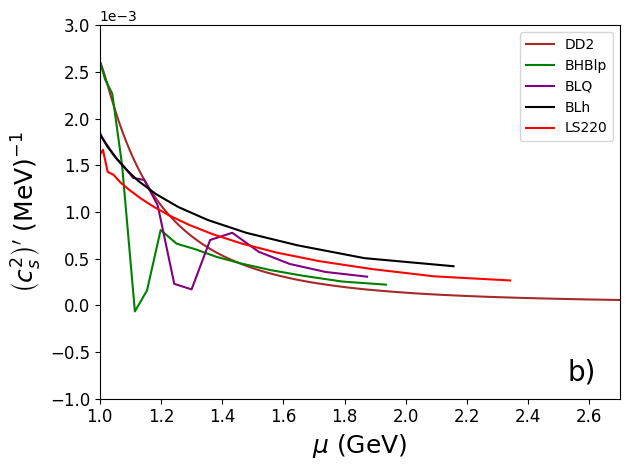

In [21]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

cs2p_mub_fig,cs2p_mub_axes = plt.subplots(1)
for eos_name in core_subeos:
    cs2p_mub_axes.plot(eos_mub[eos_name]/1000,eos_cs2p[eos_name],color=core_subeos[eos_name],label=eos_name)
    cs2p_mub_axes.set_xlim([1.0,2.7])
    cs2p_mub_axes.set_ylim([-0.001,0.003])
    
    # cs2p_mub_axes.axhline(RVSS_List["I"][2],color = RVSS_List["I"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["II"][2],color = RVSS_List["II"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["III"][2],color = RVSS_List["III"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["IV"][2],color = RVSS_List["IV"][1],linestyle='--')
    # cs2p_mub_axes.axhline(RVSS_List["V"][2],color = RVSS_List["V"][1],linestyle='--')
    #plt.axvline(core_muTOV[eos_name]/1000,color=core_subeos[eos_name])
cs2p_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$",fontsize=axes_label_fontsize)
cs2p_mub_axes.set_ylabel(r"$\left(c_s^2\right)'\text{ (MeV)}^{-1}$",fontsize=axes_label_fontsize)
cs2p_mub_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mub_axes.ticklabel_format(style='sci',axis='y',scilimits=(-3.0,-3.0))
cs2p_mub_axes.text(0.9,0.05,'b)',transform=cs2p_mub_axes.transAxes,fontsize=text_fontsize)
cs2p_mub_axes.legend()
cs2p_mub_fig.tight_layout()
# cs2p_mub_fig.savefig('./Figures/Final_Paper_Figs/cs2p_mub.pdf',format='pdf',dpi=300)
    


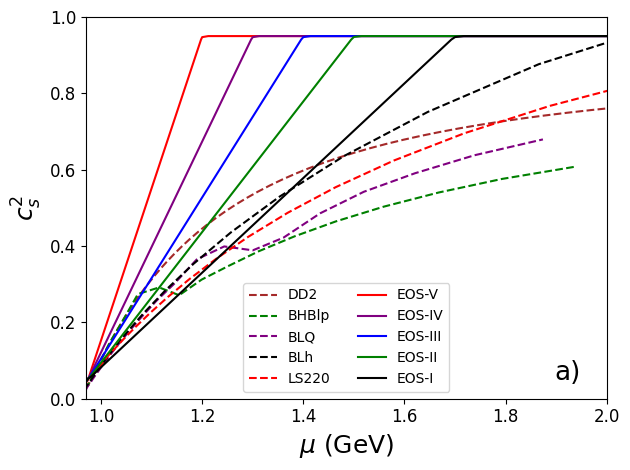

In [22]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 19
cs2_mub_fig,cs2_mub_axes = plt.subplots(1)
for eos_name in core_subeos:
    cs2_mub_axes.plot(eos_mub[eos_name]/1000,eos_cs2[eos_name],color=core_subeos[eos_name],linestyle='--',label=eos_name)
    cs2_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$")
for model in RVSS_List:
    eos = RVSS_List[model][0]
    cs2_mub_axes.plot(eos.chem_pot_unified/1000,eos.cs2_unified,color = RVSS_List[model][1],label=f'EOS-{model}')

cs2_mub_axes.set_xlim([0.970,2.0])
cs2_mub_axes.set_ylim([0.0,1.0])

cs2_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$",fontsize=axes_label_fontsize)
cs2_mub_axes.set_ylabel(r"$c_s^2$",fontsize=axes_label_fontsize)
cs2_mub_axes.tick_params(labelsize=tick_label_fontsize)
cs2_mub_axes.text(0.9,0.05,'a)',transform=cs2_mub_axes.transAxes,fontsize=text_fontsize)
cs2_mub_axes.legend(ncols=2)
cs2_mub_fig.tight_layout()
cs2_mub_fig.savefig('./Figures/Final_Paper_Figs/cs2_mub.pdf',format='pdf',dpi=300)

 

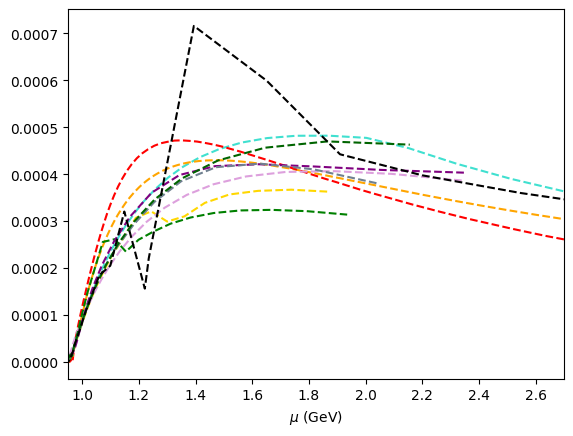

In [23]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

cs2mub_mub_fig,cs2mub_mub_axes = plt.subplots(1)
for eos_name in eos_cs2:
    cs2mub_mub_axes.plot(eos_mub[eos_name]/1000,eos_cs2[eos_name]/eos_mub[eos_name],color=eos_colors[eos_name],linestyle='--')
    cs2mub_mub_axes.set_xlim([0.950,2.700])
    cs2mub_mub_axes.set_xlabel(r"$\mu\text{ (GeV)}$")
#for model in RVSS_List:
    #eos = RVSS_List[model][0]
    #cs2_mub_axes.plot(eos.chem_pot_unified/1000,eos.cs2_unified,color = RVSS_List[model][1],label=f'EOS-{model}')

cs2p_mub_fig.tight_layout()
# cs2p_mub_fig.savefig('./Figures/Final_Paper_Figs/cs2p_mub.pdf',format='pdf',dpi=300)

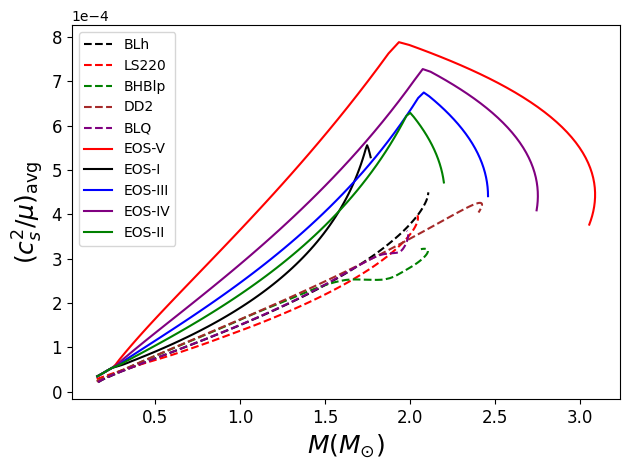

In [24]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2_mub_m_fig,cs2_mub_m_axes = plt.subplots(1)
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        cs2_mub_Vavg = data[:,6]
        mub_cs2p_Vavg = data[:,7]
        cs2_mub_m_axes.plot(M,cs2_mub_Vavg,color=core_subeos[eos],label=eos,linestyle = '--')
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    cs2_mub_Vavg = data_RVSS[:,5]
    mub_cs2p_Vavg = data_RVSS[:,6]
    cs2_mub_m_axes.plot(M,cs2_mub_Vavg,label=f'EOS-{model}',color=RVSS_List[model][1])
cs2_mub_m_axes.legend()
cs2_mub_m_axes.set_xlabel(r'$M(M_{\odot})$',fontsize=axes_label_fontsize)
cs2_mub_m_axes.set_ylabel(r'$(c_s^2/\mu)_{\text{avg}}$',fontsize=axes_label_fontsize)
cs2_mub_m_axes.tick_params(labelsize=tick_label_fontsize)
cs2_mub_m_axes.ticklabel_format(style='sci',axis='y',scilimits=(-4.0,-4.0))
cs2_mub_m_fig.tight_layout()
#cs2_mub_m_fig.savefig('./Figures/Final_Paper_Figs/cs2_mu_avg_M.pdf',format='pdf',dpi=300)




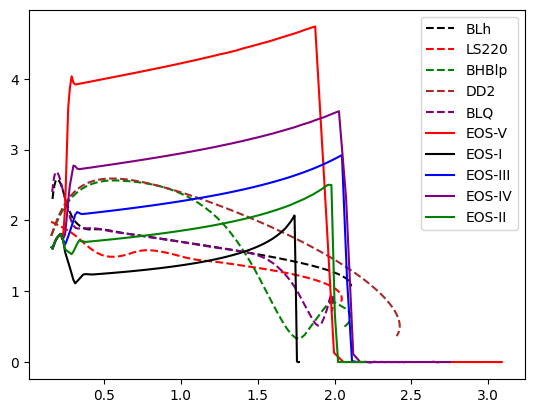

In [25]:
cs2p_mub_fig,csp_mub_axes = plt.subplots()
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        mub_cs2p_Vavg = data[:,7]
        csp_mub_axes.plot(M,mub_cs2p_Vavg,color=core_subeos[eos],linestyle = '--',label=eos)
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    mub_cs2p_Vavg = data_RVSS[:,6]
    csp_mub_axes.plot(M,mub_cs2p_Vavg,color=RVSS_List[model][1],label=f"EOS-{model}")
csp_mub_axes.legend()



In [26]:
kb_sim_dirs = {}

for eos in sim_names:
    kb_sim_dirs[eos] = SD.SimDir(os.path.abspath(os.path.join(core_db_path,eos)))
p_cut = 600

core_db_strain = {}
core_db_gws = {}
core_db_gw_phase = {}
core_db_gw_inst_freq = {}
core_db_gw_asd = {}
core_db_gw_htilde = {}

core_fpeak = {}

for sim_name in kb_sim_dirs:
    sd = kb_sim_dirs[sim_name]
    core_db_strain[sim_name] = {}
    core_db_gws[sim_name] = {}
    for gw in sd.gws:
        extr_radius = str(gw.radius)
        core_db_gws[sim_name][extr_radius] = gw
        strain = gw.get_strain_lm(2,
                                2,
                                p_cut,
                                0.1,
                                window_function='tukey')
        core_db_strain[sim_name][extr_radius] = strain

for sim in core_db_strain:
    core_db_gw_phase[sim] = {}
    core_db_gw_inst_freq[sim] = {}
    for r in core_db_strain[sim]:
        time = core_db_strain[sim][r].t
        real_h = np.real(core_db_strain[sim][r].y)
        imag_h = np.imag(core_db_strain[sim][r].y)
        phase = np.unwrap(np.arctan2(real_h,imag_h))
        
        core_db_gw_phase[sim][r] = phase
        core_db_gw_inst_freq[sim][r] = (1/(2*np.pi))*np.gradient(phase,time)
    
    core_db_gw_asd[sim] = {}
    core_db_gw_htilde[sim] = {}
    for r in core_db_strain[sim]:
        h_plus = core_db_strain[sim][r].real()
        h_cross = core_db_strain[sim][r].imag()

        h_plus_tilde = h_plus.to_FrequencySeries()
        h_cross_tilde = h_cross.to_FrequencySeries()

        h_tilde = np.sqrt((h_plus_tilde.real()**2 + h_plus_tilde.imag()**2) + (h_cross_tilde.real()**2 + h_cross_tilde.imag()**2))
        core_db_gw_htilde[sim][r] = h_tilde
        core_db_gw_asd[sim][r] = 2.0*h_tilde.fft*np.sqrt(h_tilde.f*freq_code_u_to_hz)
    core_fpeak[sim] = core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])]*freq_code_u_to_hz/1000

    sim_info[sim]['Mfpeak'] = (core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])])*(sim_info[sim]['m_total'])
    sim_info[sim]['fpeak'] = core_fpeak[sim]


<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0

/home/john/.local/lib/python3.10/site-packages/kuibit/timeseries.py:769: RuntimeWarning: TimeSeries is not regularly samples. Resampling.
  warnings.warn(


<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0x737fc57772e0>
<function tukey at 0

In [28]:
sim_info_core_subeos = {}
for sim in sim_info:
    if sim_info[sim]['eos'] in core_subeos and sim_info[sim]['m1'] == sim_info[sim]['m2'] and sim_info[sim]['spin1'] == [0.0,0.0,0.0] and sim_info[sim]['eos']:
        
        sim_info_core_subeos[sim] = sim_info[sim]
        #sim_info_core_subeos[sim]['cs2mub_Vavg'] = float(core_m_cs2_mub_Vavg_interp[sim_info[sim]['eos']](sim_info[sim]['m1']))
        p_central = core_M_pcentral_interp[sim_info[sim]['eos']](sim_info[sim]['m1'])
        solution,nu,dpdr = solver_list[sim_info[sim]['eos']].solve_nu(p_central)
        n_r = dens_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        n_c = dens_interp[sim_info[sim]['eos']](solution.y[0,0]*epsilon)
        mass = sim_info[sim]['m1']
        R = solution.t[-1]

        cs2p_r = core_cs2p_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        cs2p_r_interp = interp1d(solution.t,cs2p_r,fill_value='extrapolate')
        NS_nb_r_interp = interp1d(n_r,solution.t,fill_value='extrapolate')
        r_stop = NS_nb_r_interp((2.0/3.0)*n_c)

        idx_rstop = bisect.bisect_right(solution.t,r_stop)
 
     
        Vol,cs2p_Vavg = solver_list[sim_info[sim]['eos']].ns_vol_avg(cs2p_r[:idx_rstop],solution.t[:idx_rstop],solution.y[1,:idx_rstop],solution=solution,nu_sol=nu[:idx_rstop])
        sim_info_core_subeos[sim]['cs2p_Vavg'] = cs2p_Vavg[-1]

        print(sim_info[sim]['eos'],sim_info_core_subeos[sim]['cs2p_Vavg'])
        
        


-0.1772363201406698 -0.17723632014066984
LS220 0.0015763286156102948
-0.20206424462354847 -0.20206424462354847
BLh 0.0014658399194236063
-0.20299758143772223 -0.2029975814377222
LS220 0.0014721779155483425
-0.20027783299417676 -0.20027783299417676
BHBlp 0.001611677734118378
-0.2741705060882717 -0.27417050608827176
BLh 0.0020793199541187584
-0.21210584032879973 -0.2121058403287997
LS220 0.001426300239814935
-0.20299758143772223 -0.2029975814377222
LS220 0.0014721779155483425
-0.24749621959286883 -0.24749621959286885
DD2 0.001424539103249159
-0.22061805717912045 -0.22061805717912045
BLh 0.001398806549224799
-0.214267644495803 -0.21426764449580296
BLQ 0.001405461664174794
-0.19814544741048995 -0.19814544741048995
BHBlp 0.001619589020041802
-0.24042106751662193 -0.2404210675166219
BLh 0.0014797871235982393
-0.20547596497911802 -0.205475964979118
LS220 0.0014597398195877668
-0.23534112880044886 -0.23534112880044888
BLh 0.0014431758422617511
-0.2625582605352231 -0.26255826053522313
BLQ 0.001

In [32]:
sim_info_RVSS = {'EOS_I_1p3':{'m':1.3,'lambda':eos_I_1p3_lambda,'kappa_2T':eos_I_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[3],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["I"](1.3),'model':"I",'C':(1.3*1.477)/rvss_M_R_interp["I"](1.3)},
                 'EOS_I_1p4':{'m':1.4,'lambda':eos_I_1p4_lambda,'kappa_2T':eos_I_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[3],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["I"](1.4),'model':"I",'C':(1.4*1.477)/rvss_M_R_interp["I"](1.4)},
                 'EOS_II_1p3':{'m':1.3,'lambda':eos_II_1p3_lambda,'kappa_2T':eos_II_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[2],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["II"](1.3),'model':"II",'C':(1.3*1.477)/rvss_M_R_interp["II"](1.3)},
                 'EOS_II_1p4':{'m':1.4,'lambda':eos_II_1p4_lambda,'kappa_2T':eos_II_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[2],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["II"](1.4),'model':"II",'C':(1.4*1.477)/rvss_M_R_interp["II"](1.4)},
                 'EOS_III_1p3':{'m':1.3,'lambda':eos_III_1p3_lambda,'kappa_2T':eos_III_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[1],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["III"](1.3),'model':"III",'C':(1.3*1.477)/rvss_M_R_interp["III"](1.3)},
                 'EOS_III_1p4':{'m':1.4,'lambda':eos_III_1p4_lambda,'kappa_2T':eos_III_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[1],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["III"](1.4),'model':"III",'C':(1.4*1.477)/rvss_M_R_interp["III"](1.4)},
                 'EOS_IV_1p3':{'m':1.3,'lambda':eos_IV_1p3_lambda,'kappa_2T':eos_IV_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[4],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["IV"](1.3),'model':"IV",'C':(1.3*1.477)/rvss_M_R_interp["IV"](1.3)},
                 'EOS_IV_1p35':{'m':1.35,'lambda':eos_IV_1p35_lambda,'kappa_2T':eos_IV_kappa2T_1p35,'Mfpeak':RVSS_Mf2_list_1p35[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["IV"](1.35),'model':"IV",'C':(1.35*1.477)/rvss_M_R_interp["IV"](1.35)},
                 'EOS_V_1p3':{'m':1.3,'lambda':eos_V_1p3_lambda,'kappa_2T':eos_V_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["V"](1.3),'model':"V",'C':(1.3*1.477)/rvss_M_R_interp["V"](1.3)},
                 'EOS_V_1p4':{'m':1.4,'lambda':eos_V_1p4_lambda,'kappa_2T':eos_V_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["V"](1.4),'model': "V",'C':(1.4*1.477)/rvss_M_R_interp["V"](1.4)}}

In [27]:
for sim in sim_info_RVSS:
    sim_model = sim_info_RVSS[sim]['model']
    m = sim_info_RVSS[sim]['m']
    p_c = rvss_M_pcentral_interp[sim_model](m)
    solution,nu,a = RVSS_Solver_list[model].solve_nu(p_c)
    rad = solution.t
    M = solution.y[1,:]

    nb_r = RVSS_List[sim_model][0].nb_interp(solution.y[0,:]*epsilon)
    r_nb_interp = interp1d(nb_r,solution.t)
    r_stop = r_nb_interp((2.0/3.0)*RVSS_List[sim_model][0].nb_interp(solution.y[0,0]*epsilon))

    idx_rstop = bisect.bisect_left(rad,r_stop)
    # plt.plot(solution.t[:-1],nu)


    cs2p_r = RVSS_cs2p_interp[sim_model](solution.y[0,:]*epsilon)


    Vol,Vol_avg_cs2p = RVSS_Solver_list[sim_model].ns_vol_avg(cs2p_r[:idx_rstop],rad[:idx_rstop],solution.y[1,:idx_rstop],solution=solution,nu_sol=nu[:idx_rstop])
    sim_info_RVSS[sim]['cs2p_Vavg'] = Vol_avg_cs2p[-1]
    print(sim_info_RVSS[sim]['cs2p_Vavg'],RVSS_List[sim_model][2])    
    

-0.2408760514543927 -0.24087605145439273
0.0012394153542041 0.0012
-0.27532772131503475 -0.27532772131503475
0.001239369916200689 0.0012
-0.18832748654584375 -0.18832748654584375
0.0017110835486719514 0.0017
-0.20793353801364955 -0.20793353801364955
0.0017110194085916469 0.0017
-0.1673735166219477 -0.1673735166219477
0.0021131397971785207 0.0021
-0.18254338419593724 -0.1825433841959372
0.0021130627771024876 0.0021
-0.14846249163626216 -0.14846249163626216
0.00276215852336031 0.0027
-0.15425902668580388 -0.15425902668580388
0.002762104232207668 0.0027
-0.13051090986998765 -0.13051090986998765
0.003986608535238166 0.0039
-0.13964425092529015 -0.13964425092529015
0.003986470494571116 0.0039


In [90]:
print(sim_info_RVSS)

{'EOS_I_1p3': {'m': 1.3, 'lambda': 344.4681115398882, 'kappa_2T': 64.58777091372903, 'Mfpeak': 0.009106968810916178, 'cs2_mub_vavg': array(0.00027657), 'model': 'I', 'cs2p_Vavg': 0.0012394153542041}, 'EOS_I_1p4': {'m': 1.4, 'lambda': 185.2587290208166, 'kappa_2T': 34.73601169140311, 'Mfpeak': 0.010263929618768328, 'cs2_mub_vavg': array(0.00031475), 'model': 'I', 'cs2p_Vavg': 0.001239369916200689}, 'EOS_II_1p3': {'m': 1.3, 'lambda': 629.0182668758024, 'kappa_2T': 117.94092503921294, 'Mfpeak': 0.040155648267008986, 'cs2_mub_vavg': array(0.00030553), 'model': 'II', 'cs2p_Vavg': 0.0017110835486719514}, 'EOS_II_1p4': {'m': 1.4, 'lambda': 388.74447557751984, 'kappa_2T': 72.88958917078497, 'Mfpeak': 0.010094110503946568, 'cs2_mub_vavg': array(0.00033866), 'model': 'II', 'cs2p_Vavg': 0.0017110194085916469}, 'EOS_III_1p3': {'m': 1.3, 'lambda': 821.9518287776358, 'kappa_2T': 154.1159678958067, 'Mfpeak': 0.036348684210526325, 'cs2_mub_vavg': array(0.00033663), 'model': 'III', 'cs2p_Vavg': 0.00211

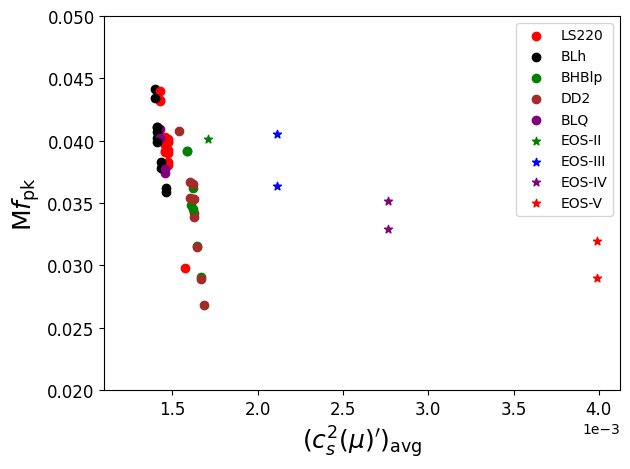

In [28]:
eos_labeled = {}
rvss_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])

for sim in sim_info_RVSS:
    if sim_info_RVSS[sim]['model'] not in rvss_labeled:
        rvss_labeled[sim_info_RVSS[sim]['model']] = False
    if sim_info_RVSS[sim]['Mfpeak'] > 0.02 and not rvss_labeled[sim_info_RVSS[sim]['model']]:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*',label=f"EOS-{sim_info_RVSS[sim]['model']}")
        rvss_labeled[sim_info_RVSS[sim]['model']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg'],sim_info_RVSS[sim]['Mfpeak'],color=RVSS_List[sim_info_RVSS[sim]['model']][1],marker='*')

cs2p_mf2_axes.set_ylim([0.02,0.05])
#cs2p_mf2_axes.set_xlim([0.00135,0.0017])

cs2p_mf2_axes.set_ylabel(r"$\text{M}f_{\text{pk}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_mf2_fig.tight_layout()
#cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_core.pdf',format='pdf',dpi=300)






In [29]:
for eos in core_mvr_data:
    print(eos,np.max(eos_cs2[eos]))

BLh 0.998001
DD2F 0.7768295315195575
DD2F-SF1 0.998001
LS220 0.9044673941218184
BHBlp 0.6073097390973933
DD2 0.9491597535294344
SLy4 0.9801
BA 0.7277591357500164
BLQ 0.6793305233065974
SFHo 0.9497602993846341


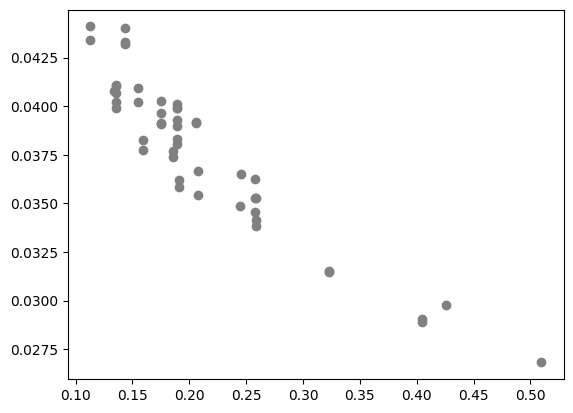

In [30]:
simulations_for_fit = {}
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02:
        plt.scatter(sim_info_core_subeos[sim]['cs2p_Vavg']*sim_info[sim]['kappa_2T'],sim_info[sim]['Mfpeak'],color='gray')
        simulations_for_fit[sim] = sim_info_core_subeos[sim]

In [31]:
k2T_cs2_mub_list = np.linspace(0,0.06,200)
k2T_list = np.linspace(50,400,200)
k2T_cs2p_list = np.linspace(0.10,0.50,200)

In [32]:
mfpk_fit = np.asarray([sim_info[sim]['Mfpeak'] for sim in simulations_for_fit])
k2T_cs2p_vavg_fit= np.asarray([sim_info[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2p_Vavg'] for sim in simulations_for_fit])

In [33]:
popt_k2t_cs2p,pcov_k2t_cs2p = curve_fit(fit_model,k2T_cs2p_vavg_fit,mfpk_fit,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p = popt_k2t_cs2p
mf2_pred = fit_model(k2T_cs2p_vavg_fit,a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p)
r2_k2t_cs2p = r2_score(mfpk_fit,mf2_pred)
print(r2_k2t_cs2p)
print(popt_k2t_cs2p)


0.9016205321175715
[5.11222114e-02 8.68072622e-08 2.10996910e+00 1.38452973e+00
 4.78607457e+00]


In [122]:
for sim in sim_info_core_subeos:
    plt.scatter(sim_info_core_subeos[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2mub_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color='gray')
for sim in sim_info_RVSS:
    plt.scatter(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'],sim_info_RVSS[sim]['Mfpeak'],color='red')

plt.gca().set_ylim([0.020,0.050])
#plt.gca().set_xlim([50,350])

plt.gca().set_xlabel(r'$(c_s^2/\mu)_{\text{avg}}\kappa^{\text{2T}}$')
plt.gca().set_ylabel(r'$\text{M}f_{\text{peak}}$')


KeyError: 'cs2mub_Vavg'

Text(0, 0.5, '$\\text{M}f_{\\text{peak}}$')

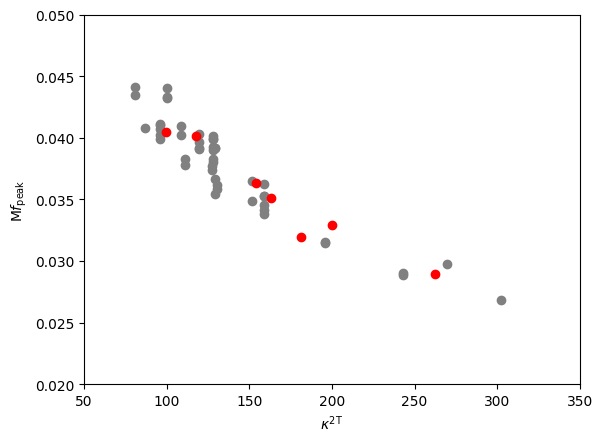

In [34]:
for sim in sim_info_core_subeos:
    plt.scatter(sim_info_core_subeos[sim]['kappa_2T'],sim_info_core_subeos[sim]['Mfpeak'],color='gray')
for sim in sim_info_RVSS:
    plt.scatter(sim_info_RVSS[sim]['kappa_2T'],sim_info_RVSS[sim]['Mfpeak'],color='red')

plt.gca().set_ylim([0.020,0.050])
plt.gca().set_xlim([50,350])

plt.gca().set_xlabel(r'$\kappa^{\text{2T}}$')
plt.gca().set_ylabel(r'$\text{M}f_{\text{peak}}$')

In [37]:
k2T = []
k2T_cs2mub = []
Mf2 = []

k2T_Rvss = []
k2T_cs2mub_rvss = []
Mf2_rvss = []

for sim in sim_info_RVSS:
    
    # k2T.append(sim_info_RVSS[sim]['kappa_2T'])
    # Mf2.append(sim_info_RVSS[sim]['Mfpeak'])
    # k2T_cs2mub.append(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'])
    k2T_Rvss.append(sim_info_RVSS[sim]['kappa_2T'])
    Mf2_rvss.append(sim_info_RVSS[sim]["Mfpeak"])
    k2T_cs2mub_rvss.append(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'])

for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.020:
        k2T.append(sim_info_core_subeos[sim]['kappa_2T'])
        Mf2.append(sim_info_core_subeos[sim]["Mfpeak"])
        #k2T_cs2mub.append(sim_info_core_subeos[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2mub_Vavg'])

        


k2T = np.asarray(k2T)
k2T_cs2mub = np.asanyarray(k2T_cs2mub)
Mf2 = np.asanyarray(Mf2)

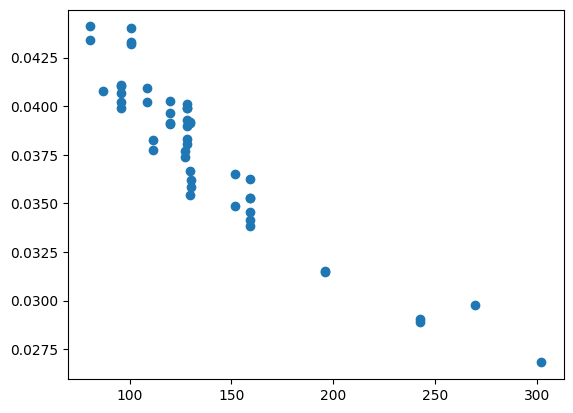

In [126]:
plt.scatter(k2T,Mf2)

In [39]:
popt_k2t,pcov_k2t = curve_fit(fit_model,k2T,Mf2,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0,a1,a2,a3,a4 = popt_k2t
mf2_pred = fit_model(k2T,a0,a1,a2,a3,a4)
print(popt_k2t)
r2_k2t = r2_score(Mf2,mf2_pred)
print(r2_k2t)

[1.65422186e-06 7.91659278e+02 3.14920691e+00 2.27130569e-11
 3.44049097e-04]
0.896623552286897


In [35]:
k2t_cs2_scaled = k2T_cs2mub*5000
popt_k2Tcs2mub,pcov_k2tcs2mub = curve_fit(fit_model,k2t_cs2_scaled,Mf2,(popt_k2t[0],popt_k2t[1],popt_k2t[2],0.1,popt_k2t[4]),maxfev=5000,method='dogbox',bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_cs,a1_cs,a2_cs,a3_cs,a4_cs = popt_k2Tcs2mub
print(popt_k2Tcs2mub)
mf2_pred = fit_model(k2t_cs2_scaled,a0_cs,a1_cs,a2_cs,a3_cs,a4_cs)
r2_k2tcs2mub = r2_score(Mf2,mf2_pred)
print(r2_k2tcs2mub)

NameError: name 'k2T_cs2mub' is not defined

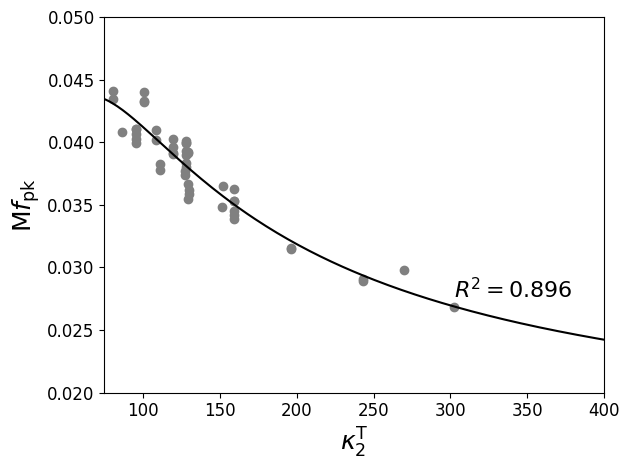

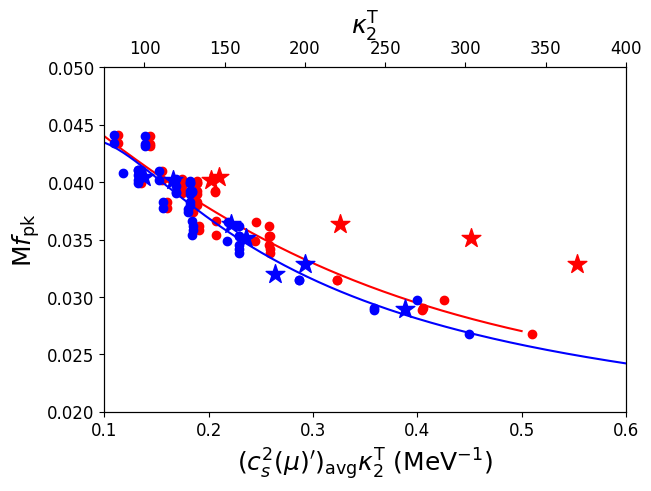

In [78]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16

kappa2T_cs2p_fig,kappa2T_cs2p_axes = plt.subplots(1,layout='constrained')
kappa2T_cs2p_axes.plot(k2T_cs2p_list,fit_model(k2T_cs2p_list,a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p),color='red')
kappa2T_cs2p_axes.scatter(k2T_cs2p_vavg_fit,mfpk_fit,color='red')
kappa2T_cs2p_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}\kappa_2^{\text{T}} \text{ (MeV}^{-1})$",fontsize=axes_label_fontsize)
kappa2T_cs2p_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
kappa2T_cs2p_axes.set_xlim([0.1,0.6])
kappa2T_cs2p_axes.set_ylim([0.02,0.05])
#kappa2T_cs2p_axes.text(0.75,0.1,r"$R^2 = 0.901$",transform=kappa2T_cs2p_axes.transAxes,fontsize=text_fontsize)
kappa2T_cs2p_axes.tick_params(labelsize=tick_label_fontsize)

for sim in sim_info_RVSS:
    kappa2T_cs2p_axes.scatter(sim_info_RVSS[sim]['cs2p_Vavg']*sim_info_RVSS[sim]['kappa_2T'],sim_info_RVSS[sim]['Mfpeak'],marker='*',color='red',s=200)


k2T_mf2_axes = kappa2T_cs2p_axes.twiny()


for sim in sim_info_RVSS:
    k2T_mf2_axes.scatter(sim_info_RVSS[sim]['kappa_2T'],sim_info_RVSS[sim]['Mfpeak'],marker='*',color='blue',s=200)

k2T_mf2_axes.scatter(k2T,Mf2,color='blue')
#k2T_mf2_axes.scatter(k2T_Rvss,Mf2_rvss,marker='*',s=125,color='red')
k2T_mf2_axes.plot(k2T_list,fit_model(k2T_list,a0,a1,a2,a3,a4),color='blue')

k2T_mf2_axes.set_xlabel(r'$\kappa_2^{\text{T}}$',fontsize=axes_label_fontsize)
k2T_mf2_axes.set_ylabel(r'$\text{M}f_{\text{pk}}$',fontsize=axes_label_fontsize)
k2T_mf2_axes.set_xlim([75,400])
k2T_mf2_axes.set_ylim([0.02,0.05])
#k2T_mf2_axes.text(0.75,0.4,r"$R^2 = 0.896$",transform=k2T_mf2_axes.transAxes,fontsize=text_fontsize)
k2T_mf2_axes.tick_params(labelsize=tick_label_fontsize)

#kappa2T_cs2p_fig.savefig("./Figures/Final_Paper_Figs/Mfpk_k2Tcs2p_vavg_k2T.pdf",format='pdf',dpi=300)

